# Immune integration: RNA-only training

Train `AmbientRegularizedSCVI` on 7-dataset immune integration (bone marrow + PBMC).
Uses early stopping with stratified validation split.

**Input**: `results/immune_integration/adata_rna.h5ad` + `scrublet_results.csv`
**Output**: Trained model + latent representation + UMAP

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
import torch
import os

import scvi
import regularizedvi

scvi.settings.progress_bar_style = "tqdm"
torch.set_float32_matmul_precision("high")
rcParams["pdf.fonttype"] = 42

## Data loading

In [2]:
from data_loading_utils import load_atac_qc_metrics, load_scrublet_scores

data_folder = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/"
rna_path = os.path.join(data_folder, "adata_rna.h5ad")
scrublet_path = os.path.join(data_folder, "scrublet_results.csv")
atac_qc_path = os.path.join(data_folder, "atac_qc_metrics.csv")

adata = sc.read_h5ad(rna_path)
print(f"Loaded: {adata.shape}")

# Load scrublet and ATAC QC using safe reindex utilities
adata = load_scrublet_scores(adata, scrublet_path)
adata = load_atac_qc_metrics(adata, atac_qc_path)

# Ensure counts in X
if "counts" in adata.layers:
    adata.X = adata.layers["counts"]

print(f"\nDatasets: {adata.obs['dataset'].nunique()}")
print(f"Batches: {adata.obs['batch'].nunique()}")
print(f"Donors: {adata.obs['donor'].nunique()}")

Loaded: (706322, 25629)


/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:425: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, index_col=0)


Scrublet: 706319/706322 matched (100.0%)


/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:437: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reindexed["predicted_doublet"] = reindexed["predicted_doublet"].fillna(False)


ATAC QC: 690590/706322 matched (97.8%)

Datasets: 7
Batches: 92
Donors: 92


## QC summary

In [3]:
# Per-dataset cell counts and QC metrics
for ds in sorted(adata.obs["dataset"].unique()):
    mask = adata.obs["dataset"] == ds
    sub = adata.obs.loc[mask]
    n_cells = mask.sum()
    n_batches = sub["batch"].nunique()
    print(f"\n{ds}: {n_cells:,} cells, {n_batches} batches")

    # Count-based QC
    total_counts = np.array(adata[mask].X.sum(1)).squeeze()
    n_genes = np.array((adata[mask].X > 0).sum(1)).squeeze()
    print(f"  Counts: median={np.median(total_counts):.0f}, range=[{total_counts.min():.0f}, {total_counts.max():.0f}]")
    print(f"  Genes:  median={np.median(n_genes):.0f}, range=[{n_genes.min():.0f}, {n_genes.max():.0f}]")

    if "mt_frac" in sub.columns:
        print(f"  MT frac: median={sub['mt_frac'].median():.3f}")
    if "doublet_score" in sub.columns:
        n_doublet = (sub["doublet_score"] > 0.18).sum()
        print(f"  Doublets (>0.18): {n_doublet} ({100 * n_doublet / n_cells:.1f}%)")

    # Annotations
    if "harmonized_annotation" in sub.columns:
        n_annot = sub["harmonized_annotation"].notna().sum()
        print(f"  Annotated: {n_annot}/{n_cells} ({100 * n_annot / n_cells:.1f}%)")


bone_marrow: 69,247 cells, 13 batches


  Counts: median=1152, range=[182, 21778]
  Genes:  median=810, range=[148, 6143]
  MT frac: median=0.006
  Doublets (>0.18): 1440 (2.1%)
  Annotated: 69247/69247 (100.0%)

covid_pbmc: 360,624 cells, 43 batches


  Counts: median=4112, range=[21, 342451]
  Genes:  median=1915, range=[19, 14448]
  MT frac: median=0.064
  Doublets (>0.18): 26553 (7.4%)
  Annotated: 0/360624 (0.0%)

crohns_pbmc: 106,296 cells, 13 batches


  Counts: median=2379, range=[34, 39529]
  Genes:  median=1322, range=[32, 7640]
  MT frac: median=0.097
  Doublets (>0.18): 7944 (7.5%)
  Annotated: 69156/106296 (65.1%)

infant_adult_spleen: 40,726 cells, 5 batches


  Counts: median=2799, range=[46, 82873]
  Genes:  median=1405, range=[24, 10067]
  MT frac: median=0.074
  Doublets (>0.18): 3126 (7.7%)
  Annotated: 0/40726 (0.0%)

lung_spleen_gse319044: 61,821 cells, 9 batches


  Counts: median=2102, range=[2, 166813]
  Genes:  median=1156, range=[2, 13017]
  MT frac: median=0.008
  Doublets (>0.18): 5565 (9.0%)
  Annotated: 20310/61821 (32.9%)

neat_seq_cd4t: 8,457 cells, 2 batches
  Counts: median=1998, range=[369, 8022]
  Genes:  median=1143, range=[304, 2959]
  MT frac: median=0.011
  Doublets (>0.18): 2128 (25.2%)
  Annotated: 8457/8457 (100.0%)

pbmc_tea_seq: 59,151 cells, 7 batches


  Counts: median=2026, range=[23, 138029]
  Genes:  median=1095, range=[23, 10153]
  MT frac: median=0.138
  Doublets (>0.18): 4787 (8.1%)
  Annotated: 26165/59151 (44.2%)


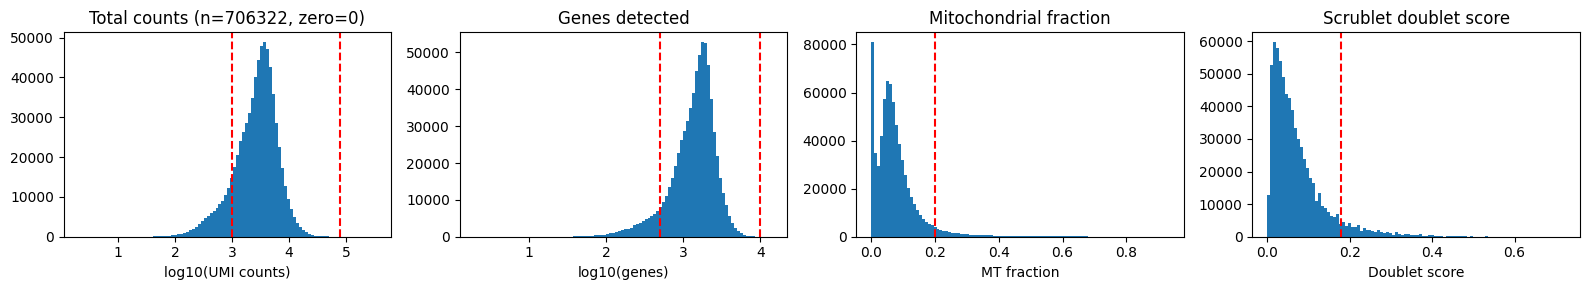

In [4]:
rcParams["figure.figsize"] = 12, 3
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

total_counts = np.array(adata.X.sum(1)).squeeze()
n_genes = np.array((adata.X > 0).sum(1)).squeeze()

axes[0].hist(np.log10(total_counts[total_counts > 0]), bins=100)
axes[0].axvline(np.log10(1000), color="red", linestyle="--")
axes[0].axvline(np.log10(80000), color="red", linestyle="--")
axes[0].set_xlabel("log10(UMI counts)")
axes[0].set_title(f"Total counts (n={len(total_counts)}, zero={np.sum(total_counts == 0)})")

axes[1].hist(np.log10(n_genes[n_genes > 0]), bins=100)
axes[1].axvline(np.log10(500), color="red", linestyle="--")
axes[1].axvline(np.log10(10000), color="red", linestyle="--")
axes[1].set_xlabel("log10(genes)")
axes[1].set_title("Genes detected")

if "mt_frac" in adata.obs.columns:
    axes[2].hist(adata.obs["mt_frac"].dropna(), bins=100)
    axes[2].axvline(0.20, color="red", linestyle="--")
    axes[2].set_xlabel("MT fraction")
    axes[2].set_title("Mitochondrial fraction")

if "doublet_score" in adata.obs.columns:
    axes[3].hist(adata.obs["doublet_score"].dropna(), bins=100)
    axes[3].axvline(0.18, color="red", linestyle="--")
    axes[3].set_xlabel("Doublet score")
    axes[3].set_title("Scrublet doublet score")

plt.tight_layout()
plt.show()

## Cell filtering

In [5]:
from data_loading_utils import adaptive_qc_filter

adata = adaptive_qc_filter(
    adata,
    min_counts=900,
    min_genes=600,
    min_fragments=1500,
    per_dataset_quantile=0.20,
)

Stage 1 (global): 706,322 -> 481,195 (225,127 removed)
Stage 2 (per-dataset q20%): 706,322 -> 475,641 (230,681 removed)
Combined: 706,322 -> 415,902 (290,420 removed)

Per-dataset 20% cutoffs:
metric                 n_genes  total_counts  total_fragments
dataset                                                      
bone_marrow              501.0         663.0           4106.0
covid_pbmc              1342.0        2465.0           1832.0
crohns_pbmc              849.0        1364.0           2282.0
infant_adult_spleen      818.0        1345.0           2425.2
lung_spleen_gse319044    663.0         987.0           3252.0
neat_seq_cd4t            995.0        1636.0           1484.0
pbmc_tea_seq             697.0        1212.0           3438.0

All 92 batches have >= 100 cells

Total: 706,322 -> 415,902 (58.9% kept)


## Gene filtering

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


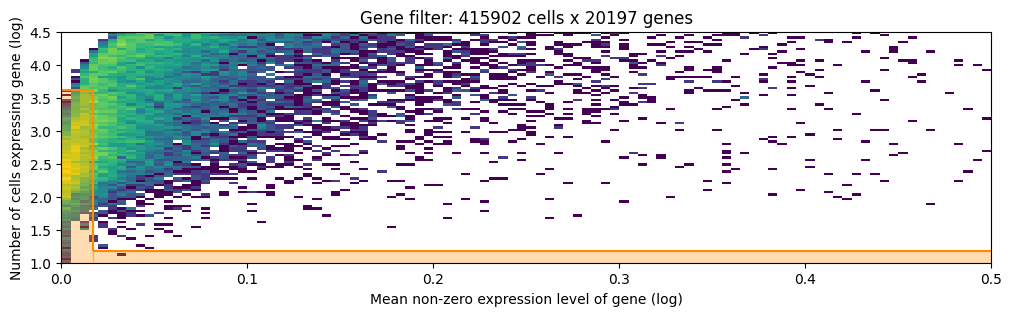

Selected 20,197 genes


In [6]:
from regularizedvi.utils import filter_genes

selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.04,
)
adata = adata[:, selected].copy()
print(f"Selected {adata.n_vars:,} genes")

In [7]:
adata.layers["counts"] = adata.X

## Model parameters

In [8]:
# Papermill parameters
results_folder = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_rna/"
additive_bg_prior_alpha = 1.0
additive_bg_prior_beta = 100.0
use_additive_background = 1
regularise_background = 0
compute_pearson = 1
use_feature_scaling = 1
library_log_means_centering_sensitivity = 1.0
library_log_vars_weight = 0.5
px_r_init_mean = None
px_r_init_std = None
additive_bg_init_mean = None
additive_bg_init_std = None
stratify_validation_key = "harmonized_annotation+batch"
early_stopping_min_delta_per_feature = 0.0002
early_stopping_patience = 10
max_epochs = 2000
wandb_project = "regularizedVI"
wandb_name = "immune_rna_base"
wandb_entity = None
wandb_notes = "RNA: libvar=0.5, stratified, ES=2e-4, patience=10. 7-dataset immune integration, 512h/128z."
wandb_group = "immune_integration"

In [9]:
from regularizedvi.utils import coerce_papermill_params, finish_wandb, log_figure_to_wandb, setup_wandb_logger

params = coerce_papermill_params(
    additive_bg_prior_alpha=(additive_bg_prior_alpha, float),
    additive_bg_prior_beta=(additive_bg_prior_beta, float),
    use_additive_background=(use_additive_background, bool),
    regularise_background=(regularise_background, bool),
    compute_pearson=(compute_pearson, bool),
    use_feature_scaling=(use_feature_scaling, bool),
    library_log_means_centering_sensitivity=(library_log_means_centering_sensitivity, "float_or_none"),
    library_log_vars_weight=(library_log_vars_weight, float),
    px_r_init_mean=(px_r_init_mean, "float_or_none"),
    px_r_init_std=(px_r_init_std, "float_or_none"),
    additive_bg_init_mean=(additive_bg_init_mean, "float_or_none"),
    additive_bg_init_std=(additive_bg_init_std, "float_or_none"),
    stratify_validation_key=(stratify_validation_key, "str_or_none"),
    early_stopping_min_delta_per_feature=(early_stopping_min_delta_per_feature, "float_or_none"),
    early_stopping_patience=(early_stopping_patience, int),
    max_epochs=(max_epochs, int),
    wandb_project=(wandb_project, "str_or_none"),
    wandb_name=(wandb_name, "str_or_none"),
    wandb_entity=(wandb_entity, "str_or_none"),
    wandb_notes=(wandb_notes, "str_or_none"),
    wandb_group=(wandb_group, "str_or_none"),
)
additive_bg_prior_alpha = params["additive_bg_prior_alpha"]
additive_bg_prior_beta = params["additive_bg_prior_beta"]
use_additive_background = params["use_additive_background"]
regularise_background = params["regularise_background"]
compute_pearson = params["compute_pearson"]
use_feature_scaling = params["use_feature_scaling"]
library_log_means_centering_sensitivity = params["library_log_means_centering_sensitivity"]
library_log_vars_weight = params["library_log_vars_weight"]
px_r_init_mean = params["px_r_init_mean"]
px_r_init_std = params["px_r_init_std"]
additive_bg_init_mean = params["additive_bg_init_mean"]
additive_bg_init_std = params["additive_bg_init_std"]
stratify_validation_key = params["stratify_validation_key"]
early_stopping_min_delta_per_feature = params["early_stopping_min_delta_per_feature"]
early_stopping_patience = params["early_stopping_patience"]
max_epochs = params["max_epochs"]
wandb_project = params["wandb_project"]
wandb_name = params["wandb_name"]
wandb_entity = params["wandb_entity"]
wandb_notes = params["wandb_notes"]
wandb_group = params["wandb_group"]

os.makedirs(results_folder, exist_ok=True)

wandb_loggers, wandb_run = setup_wandb_logger(
    wandb_project=wandb_project,
    wandb_name=wandb_name,
    wandb_entity=wandb_entity,
    wandb_notes=wandb_notes,
    wandb_group=wandb_group,
    config={
        "additive_bg_prior_alpha": additive_bg_prior_alpha,
        "additive_bg_prior_beta": additive_bg_prior_beta,
        "use_additive_background": use_additive_background,
        "regularise_background": regularise_background,
        "compute_pearson": compute_pearson,
        "use_feature_scaling": use_feature_scaling,
        "library_log_means_centering_sensitivity": library_log_means_centering_sensitivity,
        "library_log_vars_weight": library_log_vars_weight,
        "stratify_validation_key": stratify_validation_key,
        "early_stopping_min_delta_per_feature": early_stopping_min_delta_per_feature,
        "early_stopping_patience": early_stopping_patience,
        "n_hidden": 512,
        "n_latent": 128,
        "n_layers": 1,
    },
    results_folder=results_folder,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: vitkl (Cell2state-Stormi-Models) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: setting up run 198e7009


wandb: Tracking run with wandb version 0.25.0


wandb: Run data is saved locally in /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_rna/wandb/wandb/run-20260314_150226-198e7009
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run immune_rna_base


wandb: ⭐️ View project at https://wandb.ai/Cell2state-Stormi-Models/regularizedVI


wandb: 🚀 View run at https://wandb.ai/Cell2state-Stormi-Models/regularizedVI/runs/198e7009


## Model setup and training

In [10]:
regularizedvi.AmbientRegularizedSCVI.setup_anndata(
    adata,
    layer="counts",
    ambient_covariate_keys=["batch"],
    nn_conditioning_covariate_keys=["dataset", "donor"],
    feature_scaling_covariate_keys=["dataset", "donor"] if use_feature_scaling else [],
    dispersion_key="batch",
    library_size_key="batch",
)

In [11]:
model = regularizedvi.AmbientRegularizedSCVI(
    adata,
    n_hidden=512,
    n_layers=1,
    n_latent=128,
    use_additive_background=use_additive_background,
    additive_bg_prior_alpha=additive_bg_prior_alpha,
    additive_bg_prior_beta=additive_bg_prior_beta,
    regularise_background=regularise_background,
    compute_pearson=compute_pearson,
    library_log_means_centering_sensitivity=library_log_means_centering_sensitivity,
    library_log_vars_weight=library_log_vars_weight,
    px_r_init_mean=px_r_init_mean,
    px_r_init_std=px_r_init_std,
    additive_bg_init_mean=additive_bg_init_mean,
    additive_bg_init_std=additive_bg_init_std,
)

print(f"Additive background: {use_additive_background}")
print(f"Regularise background: {regularise_background}")
print(f"Compute Pearson: {compute_pearson}")
print(f"Library centering sensitivity: {library_log_means_centering_sensitivity}")
print(f"Library log vars weight: {library_log_vars_weight}")

Additive background: True
Regularise background: False
Compute Pearson: True
Library centering sensitivity: 1.0
Library log vars weight: 0.5


In [12]:
import time
from scvi.train import SaveCheckpoint

checkpoint_cb = SaveCheckpoint(
    dirpath=f"{results_folder}/checkpoints",
    every_n_epochs=200,
    save_top_k=-1,
    filename="epoch-{epoch}",
)

_es_kwargs = {}
if early_stopping_min_delta_per_feature is not None:
    _es_kwargs["early_stopping_min_delta_per_feature"] = early_stopping_min_delta_per_feature

_ds_kwargs = {"num_workers": 7}
if stratify_validation_key is not None:
    from sklearn.model_selection import train_test_split

    keys = stratify_validation_key.split("+")
    strat_labels = adata.obs[keys[0]].astype(str)
    for k in keys[1:]:
        strat_labels = strat_labels + "_" + adata.obs[k].astype(str)
    counts = strat_labels.value_counts()
    rare = counts[counts < 2].index
    if len(rare) > 0:
        strat_labels = strat_labels.replace(rare, "_rare_")
        print(f"Merged {len(rare)} rare strata into '_rare_'")
    all_idx = np.arange(adata.n_obs)
    train_idx, val_idx = train_test_split(all_idx, test_size=0.1, stratify=strat_labels.values, random_state=42)
    _ds_kwargs["external_indexing"] = [train_idx, val_idx]
    print(f"Stratified split by {stratify_validation_key}: {len(train_idx)} train, {len(val_idx)} val")

t0 = time.time()
model.train(
    check_val_every_n_epoch=1,
    train_size=0.9,
    max_epochs=max_epochs,
    batch_size=1024,
    early_stopping=True,
    early_stopping_patience=early_stopping_patience,
    early_stopping_monitor="elbo_validation",
    enable_checkpointing=True,
    callbacks=[checkpoint_cb],
    logger=wandb_loggers,
    datasplitter_kwargs=_ds_kwargs,
    **_es_kwargs,
)
elapsed = time.time() - t0
n_epochs = len(model.history_["elbo_train"])
print(f"Training: {elapsed / 60:.1f} min, {n_epochs} epochs, {elapsed / n_epochs:.2f} s/epoch")

Merged 25 rare strata into '_rare_'


Stratified split by harmonized_annotation+batch: 374311 train, 41591 val


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 6031.047. Signaling Trainer to stop.
Training: 68.3 min, 91 epochs, 45.02 s/epoch


## Results

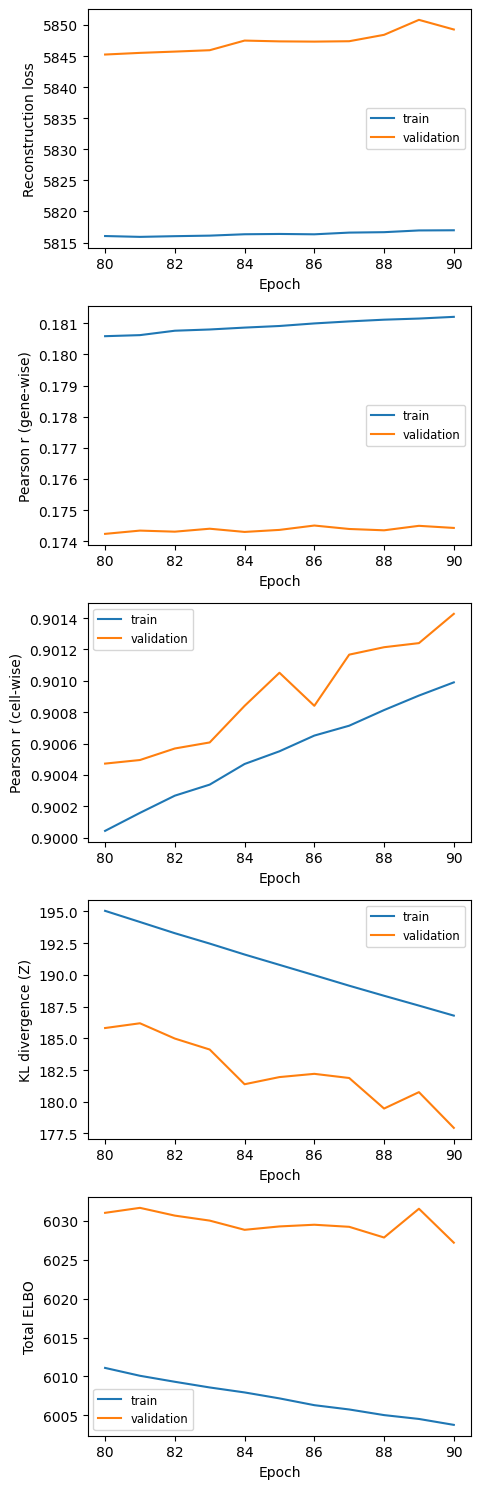

In [13]:
fig = model.plot_training_diagnostics(skip_epochs=80)
log_figure_to_wandb("training_diagnostics", fig)
plt.show()

In [14]:
ref_run_name = f"{results_folder}/model"
model.save(ref_run_name, overwrite=True)

In [15]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
print(f"Latent representation shape: {latent.shape}")

Latent representation shape: (415902, 128)


In [16]:
k = 50
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=k, metric="euclidean")
sc.tl.umap(adata, min_dist=0.4, spread=1.3)
sc.tl.leiden(adata, resolution=12, flavor="igraph")

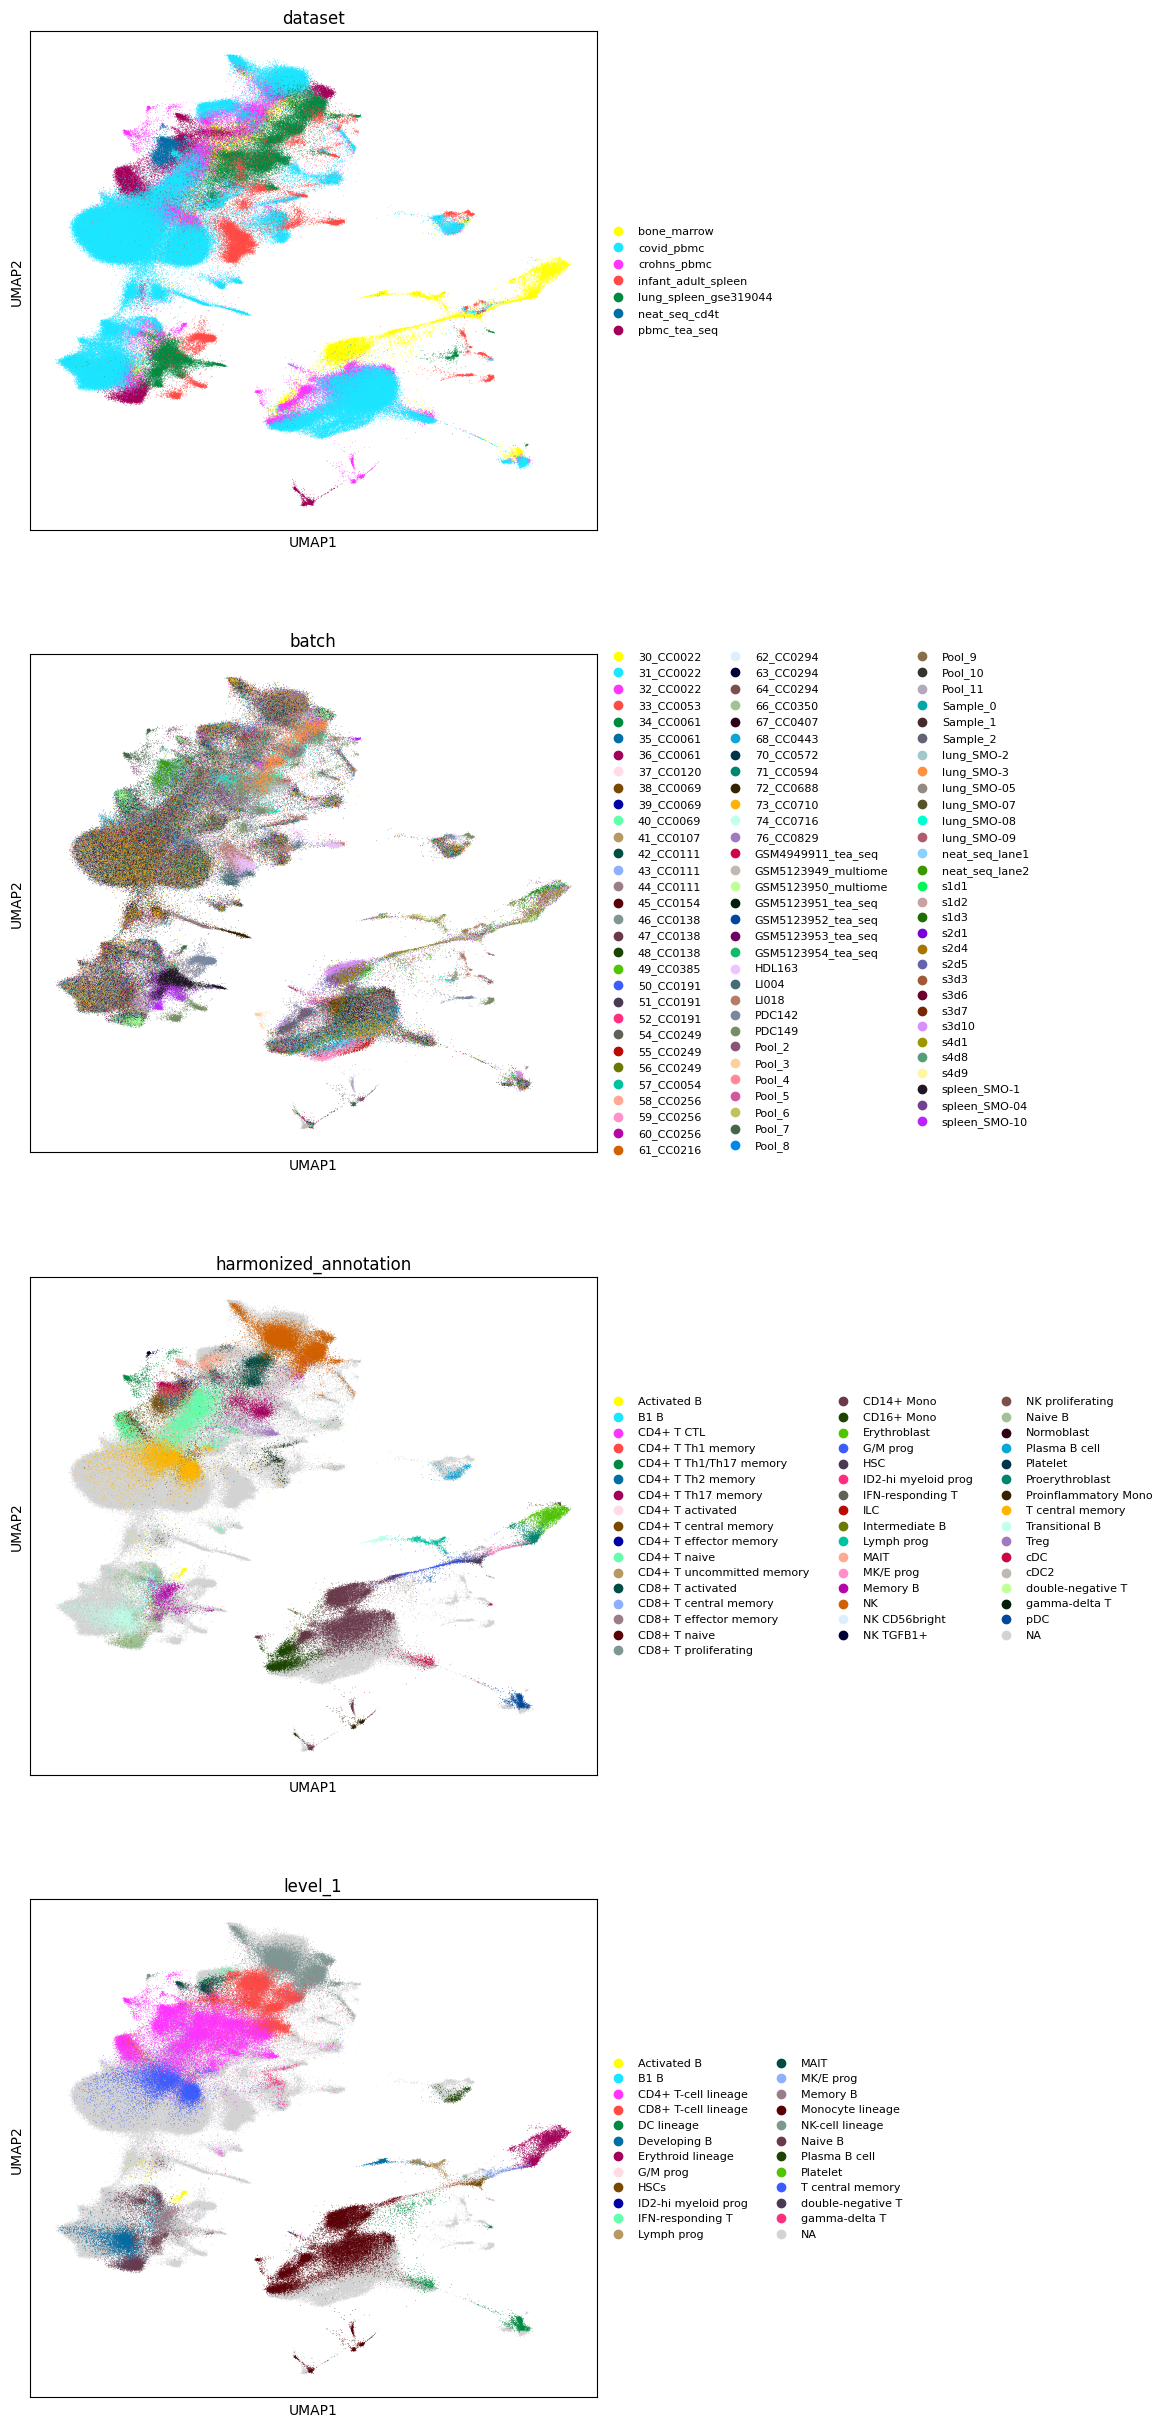

In [17]:
color = ["dataset", "batch", "harmonized_annotation", "level_1"]

rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color=color,
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=1,
    vmin=0,
    vmax="p99.9",
    use_raw=False,
    legend_fontsize=8,
)

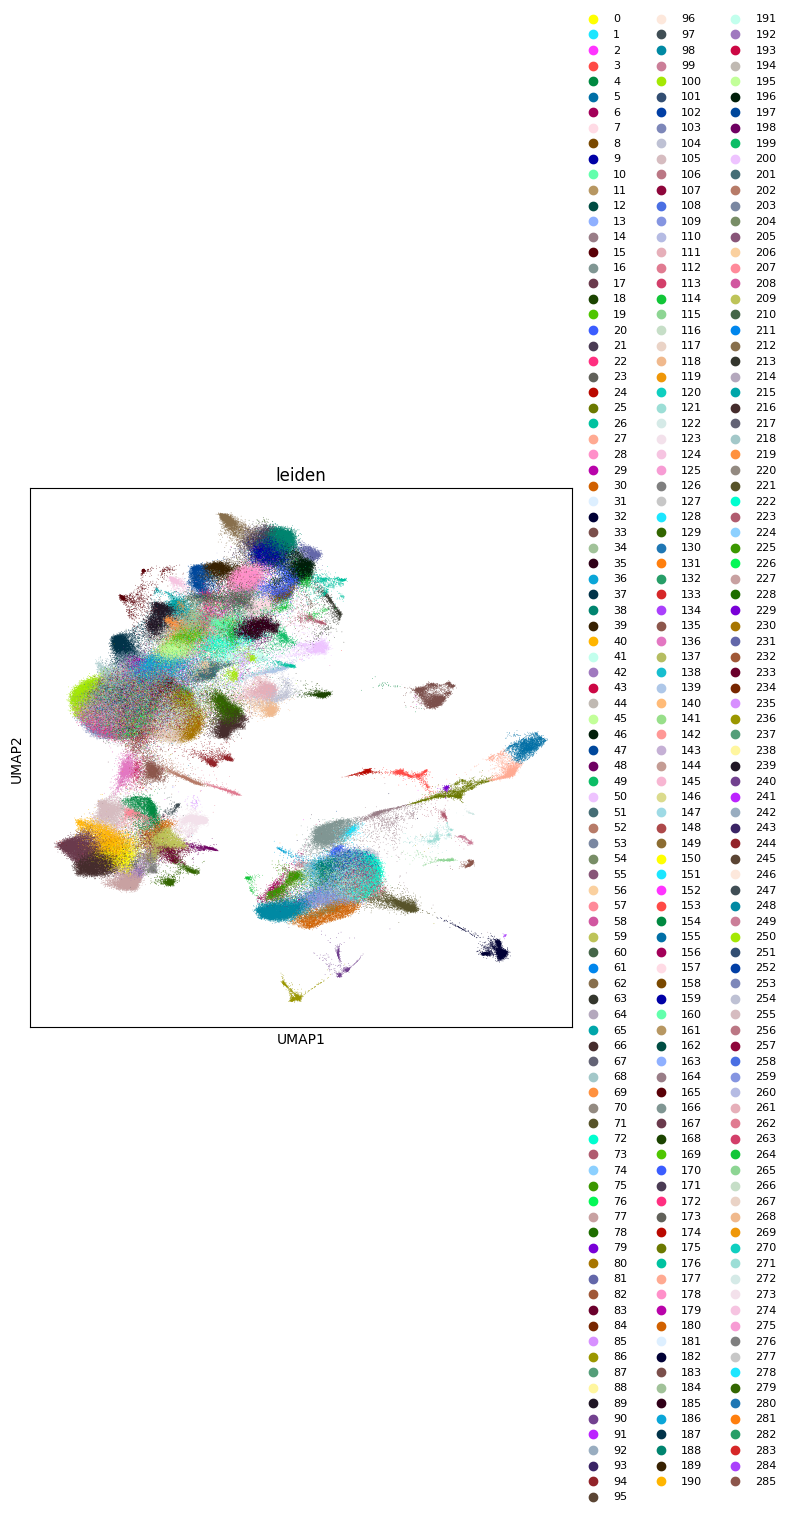

In [18]:
# Leiden clusters
rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color="leiden",
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=1,
    legend_fontsize=8,
)

In [19]:
output_dir = f"{ref_run_name}/outputs/"
os.makedirs(output_dir, exist_ok=True)

X_scVI = pd.DataFrame(
    adata.obsm["X_scVI"],
    index=adata.obs_names,
    columns=range(adata.obsm["X_scVI"].shape[1]),
)
X_scVI.to_csv(f"{output_dir}/X_scVI.csv")

X_umap = pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names,
    columns=range(2),
)
X_umap.to_csv(f"{output_dir}/X_umap_k{k}.csv")

adata.obs[["leiden"]].to_csv(f"{output_dir}/leiden_k{k}.csv")

scipy.sparse.save_npz(f"{output_dir}/distances_euclidean_k{k}.npz", adata.obsp["distances"], compressed=True)
scipy.sparse.save_npz(f"{output_dir}/connectivities_euclidean_k{k}.npz", adata.obsp["connectivities"], compressed=True)

print(f"Outputs saved to {output_dir}")

Outputs saved to /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_rna//model/outputs/


In [20]:
finish_wandb()

wandb: updating run metadata


wandb: uploading wandb-summary.json; uploading config.yaml


wandb: 
wandb: Run history:
wandb:              elbo_train █▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:         elbo_validation █▆▄▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:         kl_global_train ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    kl_global_validation ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          kl_local_train █▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     kl_local_validation ███▇▇▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:               kl_weight ▁▁▁▁▁▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇█████
wandb:      pearson_cell_train ▁▆▇▇▇███████████████████████████████████
wandb: pearson_cell_validation ▁▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
wandb:      pearson_gene_train ▁▆▆▇▇▇▇▇▇▇██████████████████████████████
wandb:                      +6 ...
wandb: 
wandb: Run summary:
wandb:              elbo_train 6003.75684
wandb:         elbo_validation 6027.20605
wandb:         kl_global_train 0
wandb:    kl_global_validation 0
wandb:          kl_local_train 186.7893

wandb: 🚀 View run immune_rna_base at: https://wandb.ai/Cell2state-Stormi-Models/regularizedVI/runs/198e7009
wandb: ⭐️ View project at: https://wandb.ai/Cell2state-Stormi-Models/regularizedVI
wandb: Synced 4 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_rna/wandb/wandb/run-20260314_150226-198e7009/logs
